<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%208%20-%20Cameron's%20Version/regime%201/07_backprop_100M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 8 — ViT · Backprop **100M** (ceiling reference)
A ~100M ViT trained by Adam+cross-entropy on MNIST classification.

## Step 0 — Setup

In [1]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Built for an A100 Colab runtime; set SMOKE=True to sanity-check on CPU.')

torch 2.11.0+cu128 | device: cuda


## Config (100M, backprop)

In [2]:
METHOD = 'backprop_100M'
LR_BP = 3e-4
METHOD_CFG = dict(LR_BP=LR_BP)
IMG, PATCH, IN_CH, NUM_CLASSES = 28, 7, 1, 10
EMBED_DIM, DEPTH, HEADS, MLP_RATIO = 1024, 12, 16, 2   # ~101M
BATCH = 64
EVAL_BATCH = 1000
DRIVE_SUBDIR = 'Section8_regime1'

TIME_BUDGET_HOURS = 2.0
SEED = 0
LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 30, 120, 1800, 60
USE_DRIVE = True
SMOKE = False
if SMOKE:
    EMBED_DIM, DEPTH, HEADS = 64, 2, 2
    TIME_BUDGET_HOURS = 30/3600
    LOG_EVERY_SEC,CKPT_EVERY_SEC,PLOT_EVERY_SEC,HEARTBEAT_EVERY_SEC=1,2,999,1
    EVAL_BATCH,USE_DRIVE=1000,False

## Step 1 — Storage (Drive) + paths

In [3]:
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed -> local /content (will NOT survive disconnect):', e)
        STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results')
CKPT_DIR    = os.path.join(STORE, 'checkpoints')
FIG_DIR     = os.path.join(STORE, 'figures')
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, f'{METHOD}.json')
CKPT_PATH    = os.path.join(CKPT_DIR,    f'{METHOD}.pt')
print('storing under:', STORE)

Mounted at /content/drive
storing under: /content/drive/MyDrive/Section8_regime1


## Step 2 — Model

In [4]:
import math, torch
import torch.nn as nn
import torch.nn.functional as F

class MHSA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0, "EMBED_DIM must be divisible by HEADS"
        self.h, self.dh = heads, dim // heads
        self.scale = self.dh ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.softmax(dim=-1)
        o = (att @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(o)

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = MHSA(dim, heads)
        self.n2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, h), nn.GELU(), nn.Linear(h, dim))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        x = x + self.mlp(self.n2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img=28, patch=7, in_ch=1, dim=176, depth=4, heads=8,
                 mlp_ratio=2, num_classes=10):
        super().__init__()
        assert img % patch == 0
        self.n = (img // patch) ** 2
        self.patch = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, self.n + 1, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.cls, std=0.02)
        self.blocks = nn.ModuleList([Block(dim, heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch(x).flatten(2).transpose(1, 2)      # (B, n, dim)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)[:, 0]
        return self.head(x)

## Step 3 — Data

In [5]:
import torchvision
train_ds = torchvision.datasets.MNIST('./data', train=True,  download=True)
test_ds  = torchvision.datasets.MNIST('./data', train=False, download=True)
mean, std = 0.1307, 0.3081
Xtr = ((train_ds.data.float()/255.0 - mean)/std).unsqueeze(1).to(device)
Ytr = train_ds.targets.to(device)
Xte = ((test_ds.data.float()/255.0 - mean)/std).unsqueeze(1).to(device)
Yte = test_ds.targets.to(device)
print('MNIST train', tuple(Xtr.shape), '| test', tuple(Xte.shape))

def fresh_batch(n):
    idx = torch.randint(0, Xtr.shape[0], (n,), device=device)
    return Xtr[idx], Ytr[idx]

100%|██████████| 9.91M/9.91M [00:00<00:00, 48.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 897kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


MNIST train (60000, 1, 28, 28) | test (10000, 1, 28, 28)


## Step 4 — Build (100M) + provenance

In [6]:
import math
torch.manual_seed(SEED)
model = ViT(IMG, PATCH, IN_CH, EMBED_DIM, DEPTH, HEADS, MLP_RATIO, NUM_CLASSES).to(device)
P = sum(p.numel() for p in model.parameters())
NUM_TOK = (IMG//PATCH)**2 + 1
print(f'METHOD={METHOD} | ViT P = {P:,} (target ~100M) | dim={EMBED_DIM} depth={DEPTH} heads={HEADS}')
CFG = dict(METHOD=METHOD, SEED=SEED, PATCH=PATCH, EMBED_DIM=EMBED_DIM, DEPTH=DEPTH, HEADS=HEADS, MLP_RATIO=MLP_RATIO, BATCH=BATCH, TIME_BUDGET_HOURS=TIME_BUDGET_HOURS)
CFG.update(METHOD_CFG)

METHOD=backprop_100M | ViT P = 100,880,394 (target ~100M) | dim=1024 depth=12 heads=16


## Step 5 — Trainer (Adam backprop)

In [7]:
torch.manual_seed(SEED)
net = ViT(IMG, PATCH, IN_CH, EMBED_DIM, DEPTH, HEADS, MLP_RATIO, NUM_CLASSES).to(device)
opt = torch.optim.Adam(net.parameters(), lr=LR_BP)

def forward_fn(x): return net(x)

def train_step():
    xb, yb = fresh_batch(BATCH)
    opt.zero_grad(); loss = F.cross_entropy(net(xb), yb); loss.backward(); opt.step()
    return loss.item()

def ckpt_state():      return {'net': net.state_dict(), 'opt': opt.state_dict()}
def load_ckpt_state(d): net.load_state_dict(d['net']); opt.load_state_dict(d['opt'])

## Step 6 — Eval / checkpoint / live-plot

In [8]:
@torch.no_grad()
def eval_metrics():
    correct = tot = 0; loss_sum = 0.0
    for i in range(0, Xte.shape[0], EVAL_BATCH):
        logits = forward_fn(Xte[i:i+EVAL_BATCH]); yb = Yte[i:i+EVAL_BATCH]
        correct += (logits.argmax(-1) == yb).sum().item(); tot += yb.numel()
        loss_sum += F.cross_entropy(logits, yb, reduction='sum').item()
    return loss_sum/tot, correct/tot

In [9]:
def _atomic_save(obj, path):
    tmp = path + '.tmp'; torch.save(obj, tmp); os.replace(tmp, path)

def save_checkpoint(step, elapsed, logs):
    _atomic_save({'loop': {'step': step, 'elapsed_sec': elapsed, 'logs': logs},
                  'method': ckpt_state(), 'config': CFG}, CKPT_PATH)

def maybe_resume():
    if os.path.exists(CKPT_PATH):
        d = torch.load(CKPT_PATH, map_location=device)
        load_ckpt_state(d['method']); L = d['loop']
        print(f'[resume] {METHOD}: step {L["step"]:,}, elapsed {L["elapsed_sec"]/3600:.2f}h -> continuing.')
        return L['step'], L['elapsed_sec'], L['logs']
    return 0, 0.0, []

In [10]:
def live_plot(logs, final=False):
    if not logs: return
    hrs = [l[0]/3600 for l in logs]
    tr  = [l[3] for l in logs]; te = [l[4] for l in logs]; ac = [l[5] for l in logs]
    if not final: clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hrs, tr, '-',  color='#999', label='train loss')
    ax[0].plot(hrs, te, 'o-', color='#C62828', label='test loss')
    ax[0].set_xlabel('elapsed hours'); ax[0].set_ylabel('loss')
    ax[0].set_title(f'{METHOD}: loss vs time'); ax[0].legend()
    ax[1].plot(hrs, ac, 'o-', color='#1F3864')
    ax[1].set_xlabel('elapsed hours'); ax[1].set_ylabel('test accuracy'); ax[1].set_title('accuracy vs time')
    plt.tight_layout()
    try: fig.savefig(os.path.join(FIG_DIR, f'{METHOD}_progress.png'), dpi=90)
    except Exception as e: print('savefig failed:', e)
    plt.show()
    last = logs[-1]
    print(f'[h={last[0]/3600:.2f}] step={last[1]:,} epoch={last[2]:.3f} test_loss={last[4]:.4f} acc={last[5]:.3f}')

## Step 7 — Train (equal wall-clock, heartbeat) + save results

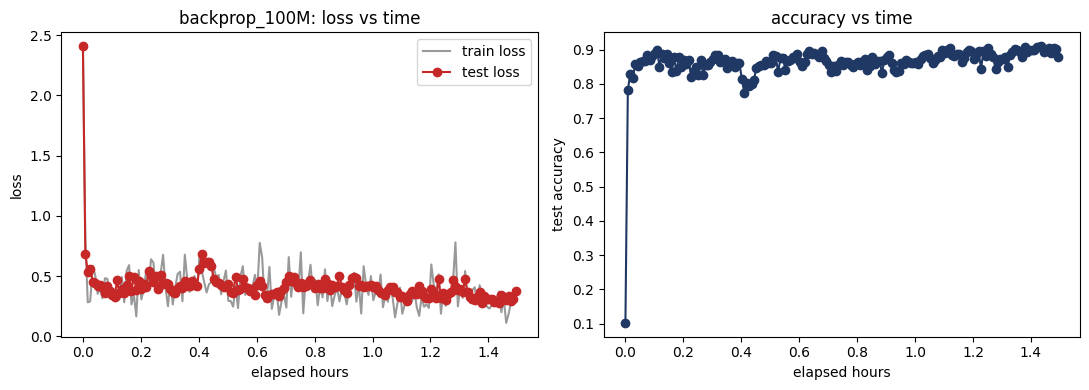

[h=1.49] step=86,420 epoch=92.181 test_loss=0.3740 acc=0.879
[backprop_100M] h=1.50 step=86,816 train=0.3754 test=0.3740 acc=0.879
[backprop_100M] h=1.52 step=87,812 train=0.3939 test=0.3243 acc=0.895
[backprop_100M] h=1.54 step=88,753 train=0.3470 test=0.3193 acc=0.894
[backprop_100M] h=1.55 step=89,739 train=0.4516 test=0.3716 acc=0.880
[backprop_100M] h=1.57 step=90,680 train=0.3728 test=0.3092 acc=0.899
[backprop_100M] h=1.59 step=91,669 train=0.2689 test=0.2775 acc=0.913
[backprop_100M] h=1.60 step=92,604 train=0.3240 test=0.3107 acc=0.903
[backprop_100M] h=1.62 step=93,590 train=0.3106 test=0.2762 acc=0.915
[backprop_100M] h=1.64 step=94,524 train=0.1711 test=0.2715 acc=0.914
[backprop_100M] h=1.65 step=95,509 train=0.1770 test=0.2891 acc=0.905
[backprop_100M] h=1.67 step=96,442 train=0.3001 test=0.3469 acc=0.886
[backprop_100M] h=1.69 step=97,426 train=0.3436 test=0.2585 acc=0.916
[backprop_100M] h=1.70 step=98,306 train=0.2979 test=0.2869 acc=0.908
[backprop_100M] h=1.72 step=9

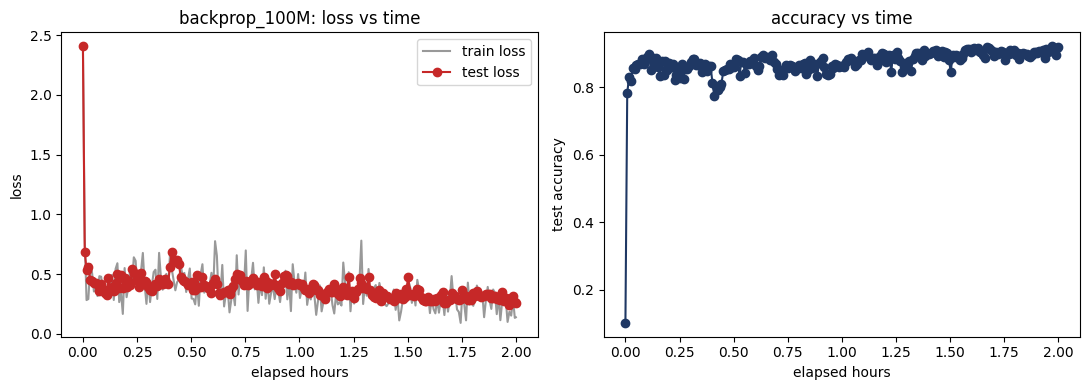

[h=2.00] step=115,417 epoch=123.111 test_loss=0.2548 acc=0.919
wrote /content/drive/MyDrive/Section8_regime1/results/backprop_100M.json
DONE backprop_100M: 115,417 steps, 2.00h, final test acc 0.919, best loss 0.2441


In [11]:
def write_results(step, elapsed, logs):
    te = [l[4] for l in logs]; ac = [l[5] for l in logs]
    summary = dict(initial_loss=logs[0][4], final_loss=logs[-1][4], best_loss=min(te),
                   reduction_pct=100*(logs[0][4]-min(te))/max(logs[0][4], 1e-9),
                   final_acc=logs[-1][5], best_acc=max(ac))
    peak = torch.cuda.max_memory_allocated()/1e6 if device == 'cuda' else float('nan')
    out = dict(meta=dict(method=METHOD, device=device, seed=SEED, P=P, config=CFG, note='all MEASURED-here',
                         wall_clock_sec=elapsed, total_steps=step, epochs=step*BATCH/60000, peak_mem_mb=peak),
               curve=dict(t_sec=[l[0] for l in logs], step=[l[1] for l in logs], epoch=[l[2] for l in logs],
                          train_loss=[l[3] for l in logs], test_loss=te, test_acc=ac),
               summary=summary)
    with open(RESULTS_PATH, 'w') as f: json.dump(out, f, indent=2)
    print('wrote', RESULTS_PATH)

def run():
    step, elapsed0, logs = maybe_resume()
    t0 = time.time(); budget = TIME_BUDGET_HOURS*3600
    last_ckpt = last_plot = last_log = last_beat = elapsed0
    if not logs:
        l0, a0 = eval_metrics(); logs.append((elapsed0, step, 0.0, l0, l0, a0))
    tl = logs[-1][3]; printed = False
    while True:
        elapsed = elapsed0 + (time.time() - t0)
        if elapsed >= budget: break
        tl = train_step(); step += 1
        if not printed:
            dt = time.time() - t0
            print(f'[{METHOD}] step 1 = {dt:.2f}s -> ~{int(budget/max(dt,1e-9)):,} steps fit the budget.', flush=True); printed = True
        if elapsed - last_log >= LOG_EVERY_SEC:
            el, ac = eval_metrics(); logs.append((elapsed, step, step*BATCH/60000, tl, el, ac)); last_log = elapsed
        if elapsed - last_beat >= HEARTBEAT_EVERY_SEC:
            L = logs[-1]
            print(f'[{METHOD}] h={elapsed/3600:.2f} step={step:,} train={L[3]:.4f} test={L[4]:.4f} acc={L[5]:.3f}', flush=True)
            last_beat = elapsed
        if elapsed - last_ckpt >= CKPT_EVERY_SEC:
            save_checkpoint(step, elapsed, logs); last_ckpt = elapsed
        if elapsed - last_plot >= PLOT_EVERY_SEC:
            live_plot(logs); last_plot = elapsed
    elapsed = elapsed0 + (time.time() - t0)
    el, ac = eval_metrics(); logs.append((elapsed, step, step*BATCH/60000, tl, el, ac))
    save_checkpoint(step, elapsed, logs); live_plot(logs, final=True); write_results(step, elapsed, logs)
    print(f'DONE {METHOD}: {step:,} steps, {elapsed/3600:.2f}h, final test acc {ac:.3f}, best loss {min(l[4] for l in logs):.4f}')

run()

## How to run
- `SMOKE=True` first (~30 s tiny model), then `False` → Runtime → Run all on an A100.
- Backprop can train 100M fine (the probe rule can't — cost ~P²), so this is the **ceiling** reference. Same equal-wall-clock harness: heartbeat, Drive checkpoint/auto-resume, live plot, `results/backprop_100M.json`.
- Reduce `BATCH` if you hit CUDA OOM.